Q2 Assume that a camera is mounted with the optical axis perpendicular to the imaging plane (where the flat earrings are kept). If the focal length of the camera is 8 mm, the pixel size is 2.2 µm× 2.2 µm, and the distance from the lens to the imaging plane is 720 mm, what are the sizes of the earrings?

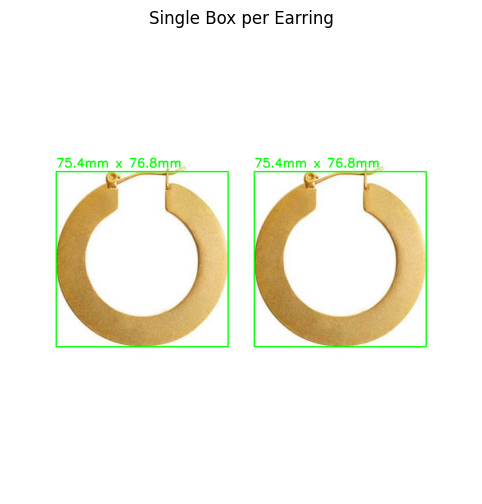

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread("/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 02/earrings.jpg")
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5,5), 0)
edges = cv.Canny(blur, 50, 150)

contours, _ = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Conversion factor: each pixel ≈ 0.198 mm
pixel_to_mm = 0.198

# Sort contours by area, top 2 (for two earrings)
contours = sorted(contours, key=cv.contourArea, reverse=True)[:2]

for cnt in contours:
    x, y, w, h = cv.boundingRect(cnt)
    width_mm = w * pixel_to_mm
    height_mm = h * pixel_to_mm
    cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv.putText(img, f"{width_mm:.1f}mm x {height_mm:.1f}mm",
               (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Single Box per Earring")
plt.axis("off")
plt.show()
